<a href="https://colab.research.google.com/github/predpoke/SuperSecondProject/blob/KAN-5-image-analysis-model/SuperPorjectCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [2]:
import torch
import torch.nn as nn


In [3]:
#SkinCAP 불러오기

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import os

skincap_metadata_path = "/content/drive/MyDrive/datasets/SkinCAP_HAM_format/skincap_ham_metadata.csv"

skincap_ham_df = pd.read_csv(skincap_metadata_path)

print(skincap_ham_df.shape)
print(skincap_ham_df.columns)
skincap_ham_df.head()

(900, 7)
Index(['image_id', 'image_name', 'image_path', 'dx', 'original_label',
       'caption', 'source'],
      dtype='object')


,image_id,image_name,image_path,dx,original_label,caption,source
0,1,1.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,mel,melanoma-in-situ,Occurs in the center of the foot. Irregularly ...,SkinCAP
1,3,3.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,akiec,squamous-cell-carcinoma-in-situ,Irregularly shaped black patches with a red ce...,SkinCAP
2,4,4.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,bcc,basal-cell-carcinoma,Occurs on the face. The skin lesions consist o...,SkinCAP
3,6,6.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,mel,melanoma-acral-lentiginous,"Black spots occur on the soles of the feet, wi...",SkinCAP
4,7,7.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,mel,melanoma-in-situ,Occurs at the edge of the nail. Irregular blac...,SkinCAP


In [ ]:
import os

for root, dirs, files, in os.walk(path) :
  print("현재 폴더  :",  root)
  print("폴더들 :", dirs[:5])
  print("파일들 :", files[:5])
  print("_" * 50)

현재 폴더  : /kaggle/input/skin-cancer-mnist-ham10000
폴더들 : ['HAM10000_images_part_1', 'ham10000_images_part_1', 'HAM10000_images_part_2', 'ham10000_images_part_2']
파일들 : ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'hmnist_8_8_L.csv', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']
__________________________________________________
현재 폴더  : /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1
폴더들 : []
파일들 : ['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']
__________________________________________________
현재 폴더  : /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1
폴더들 : []
파일들 : ['ISIC_0028933.jpg', 'ISIC_0028394.jpg', 'ISIC_0027799.jpg', 'ISIC_0028100.jpg', 'ISIC_0027960.jpg']
__________________________________________________
현재 폴더  : /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2
폴더들 : []
파일들 : ['ISIC_0030912.jpg', 'ISIC_0030585.jpg', 'ISIC_0033697.jpg', 'ISIC_0030062.jpg', 'ISIC_0031213.jpg']

In [ ]:
#여기 정리
# img_dir1 이게 지금 파일 내용임
#아래쪽 갔다가 다시 와야됨

import os
import pandas as pd

metadata_path = os.path.join(path, "HAM10000_metadata.csv")

ham_df = pd.read_csv(metadata_path)

def find_ham_image_path(image_id):
  file_name = str(image_id) + ".jpg"

  path1 = os.path.join(img_dir1, file_name)
  path2 = os.path.join(img_dir2, file_name)

  if os. path.exists(path1) :
    return path1
  elif os.path.exists(path2) :
    return path2
  else :
    return None


ham_df["image_path"] = ham_df["image_id"].apply(find_ham_image_path)

print("HAM 이미지 누락 :", ham_df["image_path"].isna().sum())
ham_df[["image_id", "dx", "image_path"]].head()

In [ ]:
ham_attach_df = ham_df.copy()

ham_attach_df["image_name"] = ham_attach_df["image_id"].astype(str) + ".jpg"
ham_attach_df["original_label"] = ham_attach_df["dx"]
ham_attach_df["caption"] = ""
ham_attach_df["source"] = "HAM10000"

common_cols =[
    "image_id",
    "image_name",
    "image_path",
    "dx",
    "original_label",
    "caption",
    "source"
]

ham_attach_df = ham_attach_df[common_cols]
skincap_attach_df = skincap_ham_df[common_cols]


ham_plus_skincap_df = pd.concat(
    [ham_attach_df, skincap_attach_df],
     ignore_index=True
)

print("HAM:", len(ham_attach_df))
print("SkinCAP :", len(skincap_attach_df))
print("통합 :", len(ham_plus_skincap_df))




In [ ]:
save_path = "/content/drive/MyDrive/datasets/HAM10000_plus_SkinCAP_metadata.csv"

ham_plus_skincap_df.to_csv(save_path, index=False, encoding="utf-8-sig")

print('저장 완료 :', save_path)

#실행 안해도 됨
#이게 경로인데, 이걸 한 번에 실행을 못하네 여기까지 안하려면 어떻게 해야하지

NameError: name 'ham_plus_skincap_df' is not defined

In [5]:
combined_df = pd.read_csv("/content/drive/MyDrive/datasets/HAM10000_plus_SkinCAP_metadata.csv")

print(combined_df.shape)
print(combined_df["source"].value_counts())
print(combined_df["dx"].value_counts())

(10915, 7)
source
HAM10000    10015
SkinCAP       900
Name: count, dtype: int64
dx
nv       6972
mel      1245
bkl      1199
bcc       682
akiec     397
vasc      269
df        151
Name: count, dtype: int64


(600, 450)


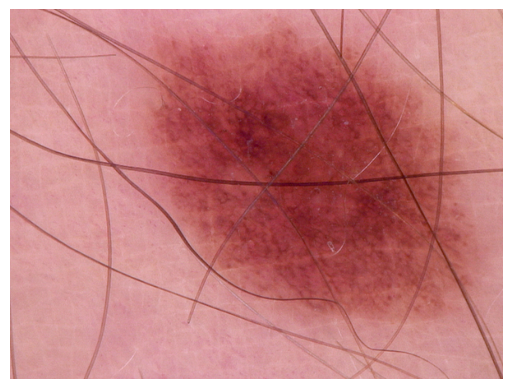

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img_dir1 = os.path.join(path, "HAM10000_images_part_1")
img_dir2 = os.path.join(path, "HAM10000_images_part_2")

sample_img = os.listdir(img_dir1)[0]
img_path = os.path.join(img_dir1, sample_img)
#그러니까 이게 처음에 파일 이름 하나만 꺼내오고
# 그 다음에 경로까지 받아와야 열린대

img = Image.open(img_path)
print(img.size)

plt.imshow(img)
plt.axis("off")
plt.show()

In [7]:
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

#즉 이 클래스는 데이터를 가공할 자료들인거지



In [ ]:
combined_df
#ham_plus_skincap_df

,image_id,image_name,image_path,dx,original_label,caption,source
0,ISIC_0027419,ISIC_0027419.jpg,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,bkl,bkl,NaN,HAM10000
1,ISIC_0025030,ISIC_0025030.jpg,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,bkl,bkl,NaN,HAM10000
2,ISIC_0026769,ISIC_0026769.jpg,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,bkl,bkl,NaN,HAM10000
3,ISIC_0025661,ISIC_0025661.jpg,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,bkl,bkl,NaN,HAM10000
4,ISIC_0031633,ISIC_0031633.jpg,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,bkl,bkl,NaN,HAM10000
...,...,...,...,...,...,...,...
10910,3972,3972.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,bcc,basal cell carcinoma,You can see light red soybean-sized hemispheri...,SkinCAP
10911,3973,3973.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,vasc,telangiectases,This is a photo of a skin lesion on the face. ...,SkinCAP
10912,3984,3984.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,mel,melanoma,You can see scattered red nodules on the right...,SkinCAP
10913,3986,3986.png,/content/drive/MyDrive/datasets/SkinCAP_HAM_fo...,bcc,basal cell carcinoma,This is a photo of a skin lesion on the dorsum...,SkinCAP


In [ ]:
#raw response
 #픽셀 단위로 바로 반응
 # 아주 작은 edge, 점, 극소 변화도 그대로 남음
 # smoothing 이나 poolign 없이 가장 예민한 상태

# max pooling
# 주변에서 가장 강한 반응 하나를 대표값으로 삼음
# 작은 강한 특징이 평균에 묻히지 않음


In [39]:
import pandas as pd
import random
from sklearn.model_selection import train_test_split
import torch.nn.functional as F


#csv_path = os.path.join(path, "HAM10000_metadata.csv")
#df = pd.read_csv(csv_path)

#print(df.head())

#이걸 자꾸 헷갈려 하는데 ,클래스 내부에 생성자잖아 그러니까 초기화 구문이어서 이걸 자꾸 어렵게 받아들이면 안됨
#그래서 내가 각각 사용할 데이터들을 전부 좀 처음부터 정리해서 쓰자 이런 느낌임



all_classes = sorted(combined_df["dx"].unique())
label2idx = {label : idx for idx, label in enumerate(all_classes)}
    #문자열을 숫자로 바꿈
idx2label = {idx : label for label, idx in label2idx.items()}
#얘는 사람이 보려고 만든거 그러니까 숫자에서 다시 라벨로 만들어줌


train_df, temp_df = train_test_split(
    combined_df,
    test_size = 0.2,
    random_state= 42,
    shuffle=True,
    stratify= combined_df["dx"]
)


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state= 42,
    shuffle=True,
    stratify=temp_df["dx"]

)



class CombinedSkinDataset(Dataset) :
  def __init__(self, df, transform=None, label2idx=None):
    self.df = df.reset_index(drop=True)
    self.transform = transform
    self.label2idx = label2idx
  def __len__(self) :
    return len(self.df)

  def __getitem__(self, idx) :
    row = self.df.iloc[idx]

    img_path = row["image_path"]
    dx = row["dx"]

    label = self.label2idx[dx]
    image = Image.open(img_path).convert("RGB")

    if self.transform is not None :
      image = self.transform(image)

    return image, label

# class AddLocalColorVarianceChannel :
#   def __call__(self, x) :
#     gray = 0.299 * x[0] + 0.587 * x[1] + 0.114 * x[2]
#     gray = gray.unsqueeze(0).unsqueeze(0)

#     local_mean = F.avg_pool2d(gray, kernel_size=5, stride=1, padding=2)

#     local_mean_sq = F.avg_pool2d(gray * gray, kernel_size=5, stride =1, padding=2)


#     local_var = local_mean_sq - local_mean * local_mean
#     local_var = torch.clamp(local_var, min=0.0)

#     local_var = local_var / (local_var.max() + 1e-6)

#     local_var =local_var.squeeze(0)
#     x = torch.cat([x, local_var], dim =0)
#     return x

# class AddLocalTextureVarianceChannel :
#   def __call__(self, x) :
#     gray = 0.299 * x[0] + 0.587 * x[1] + 0.114 * x[2]
#     gray = gray.unsqueeze(0).unsqueeze(0)

#     laplacian_kernel = torch.tensor(
#         [[0, 1, 0],
#          [1, -4, 1],
#          [0, 1, 0]],
#         dtype=torch.float32,
#         device=gray.device
#     ).view(1, 1, 3, 3)



#     texture= F.conv2d(gray,laplacian_kernel, padding=1)
#     texture = torch.abs(texture)

#     texture = F.avg_pool2d(texture, kernel_size=3, stride=1, padding=1)

#     texture = texture.squeeze(0)
#     x= torch.cat([x, texture], dim=0)

#     return x
import torch


# class AddGlobalColorDiversityChannel :
#   def __call__(self, x) :
#     rgb = x[:3]

#     diversity = torch.var(rgb, dim=0, keepdim = True)

#     diversity_4d = diversity.unsqueeze(0)
#     diversity_4d = F.avg_pool2d(diversity_4d, kernel_size=5, stride=1, padding=2 )
#     diversity = diversity_4d.squeeze(0)

#     diversity = diversity/ (diversity.max() + 1e-6)
#     x = torch.cat([x, diversity], dim=0)
#     return x


class DualBranchSkinNet(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # -------------------
        # 1) Local branch
        # -------------------
        local = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        old_conv = local.conv1

        local.conv1 = nn.Conv2d(
            in_channels=6,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        with torch.no_grad():
          rgb_weight = old_conv.weight[:, :, 2:5, 2:5]
          local.conv1.weight[:, :3] = rgb_weight
          extra_weight = rgb_weight.mean(dim=1, keepdim=True)
          local.conv1.weight[:, 3:4] = extra_weight
          local.conv1.weight[:, 4:5] = extra_weight
          local.conv1.weight[:, 5:6] = extra_weight




        local.maxpool = nn.Identity()   # 작은 특징 보존
        local.fc = nn.Identity()        # feature만 뽑기
        self.local_branch = local

        # -------------------
        # 2) Global branch
        # -------------------
        global_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        global_model.fc = nn.Identity()
        self.global_branch = global_model

        # -------------------
        # 3) Fusion classifier
        # -------------------
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        local_feat = self.local_branch(x)    # [B, 512]
        global_feat = self.global_branch(x[:, :3])  # [B, 512]

        feat = torch.cat([local_feat, global_feat], dim=1)  # [B, 1024]
        out = self.classifier(feat)
        return out


import torch
import torch.nn.functional as F

# 1. 가벼운 Boundary 채널
class AddLightBoundaryChannel:
    def __init__(self):
        self.sobel_x = torch.tensor(
            [[-1, 0, 1],
             [-2, 0, 2],
             [-1, 0, 1]],
            dtype=torch.float32
        ).view(1, 1, 3, 3)

        self.sobel_y = torch.tensor(
            [[-1, -2, -1],
             [ 0,  0,  0],
             [ 1,  2,  1]],
            dtype=torch.float32
        ).view(1, 1, 3, 3)

    def __call__(self, x):
        rgb = x[:3]
        gray = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
        gray4 = gray.unsqueeze(0).unsqueeze(0)

        sobel_x = self.sobel_x.to(gray4.device)
        sobel_y = self.sobel_y.to(gray4.device)

        gx = F.conv2d(gray4, sobel_x, padding=1)
        gy = F.conv2d(gray4, sobel_y, padding=1)

        edge = torch.sqrt(gx**2 + gy**2 + 1e-6)

        # smoothing은 최소화
        edge = F.avg_pool2d(edge, kernel_size=3, stride=1, padding=1)

        edge = edge.squeeze(0)   # [1,H,W]
        edge = edge / (edge.max() + 1e-6)

        return torch.cat([x, edge], dim=0)


# 2. 가벼운 Spread 채널
class AddLightSpreadChannel:
    def __call__(self, x):
        rgb = x[:3]
        gray = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
        gray4 = gray.unsqueeze(0).unsqueeze(0)

        # blur를 크게 하지 않고 조금만
        blur = F.avg_pool2d(gray4, kernel_size=9, stride=1, padding=4)
        contrast = torch.abs(gray4 - blur)

        # 간단 threshold
        thresh = contrast.mean() + 0.03
        mask = (contrast > thresh).float()

        # spread도 작은 커널로 단순화
        spread = F.avg_pool2d(mask, kernel_size=9, stride=1, padding=4)

        spread = spread.squeeze(0)   # [1,H,W]
        spread = spread / (spread.max() + 1e-6)

        return torch.cat([x, spread], dim=0)


# 3. 가벼운 InnerTexture 채널
class AddLightInnerTextureChannel:
    def __call__(self, x):
        rgb = x[:3]
        gray = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
        gray4 = gray.unsqueeze(0).unsqueeze(0)

        local_mean = F.avg_pool2d(gray4, kernel_size=5, stride=1, padding=2)
        local_mean_sq = F.avg_pool2d(gray4 * gray4, kernel_size=5, stride=1, padding=2)

        local_var = local_mean_sq - local_mean * local_mean
        local_var = torch.clamp(local_var, min=0.0)

        # smoothing 1번만
        texture = F.avg_pool2d(local_var, kernel_size=3, stride=1, padding=1)

        texture = texture.squeeze(0)   # [1,H,W]
        texture = texture / (texture.max() + 1e-6)

        return torch.cat([x, texture], dim=0)


# class AddAsymmetryChannel:
#     def __call__(self, x):
#         # x: [3, H, W]

#         # RGB -> grayscale
#         gray = 0.299 * x[0] + 0.587 * x[1] + 0.114 * x[2]   # [H, W]

#         # 좌우 뒤집기
#         gray_flip = torch.flip(gray, dims=[1])   # width 방향 flip

#         # asymmetry map
#         asym = torch.abs(gray - gray_flip)

#         # normalize
#         asym = asym / (asym.max() + 1e-6)

#         # 채널 추가
#         asym = asym.unsqueeze(0)   # [1, H, W]
#         x = torch.cat([x, asym], dim=0)   # [4, H, W]

#         return x



import torch
import torch.nn.functional as F

# class AddImprovedAsymmetryChannel:
#     def __call__(self, x):
#         # x: [3, H, W]
#         H, W = x.shape[1], x.shape[2]

#         # 1) RGB -> grayscale
#         gray = 0.299 * x[0] + 0.587 * x[1] + 0.114 * x[2]   # [H, W]

#         # 2) 부드러운 blur 만들어서 local contrast 계산
#         #평균 풀링으로 간단하게 흐리게 만듦
#         # 흐리게 만든 이미지를 기준점으로 삼아서, 원본이 그 기준에서 얼마나 튀는지 보는 것
#         #
#         gray_4d = gray.unsqueeze(0).unsqueeze(0)            # [1,1,H,W] 여기서 차원 추가하고
#         blur = F.avg_pool2d(gray_4d, kernel_size=15, stride=1, padding=7).squeeze(0).squeeze(0) #다시 차원 축소
#         contrast = torch.abs(gray - blur)

#         # 3) 중앙 가중치 (배경보다 중심부를 더 믿기 위해)
#         # linsapce : -1 부터 1까지를 H개르 균등하게 나눈 숫자 배열
#         # 이미지 안 모든 픽셀에 대해 중심에서 얼마나 떨어져 있냐를 계산하기 위함

#         yy, xx = torch.meshgrid(
#             torch.linspace(-1, 1, H, device=x.device),
#             torch.linspace(-1, 1, W, device=x.device),
#             indexing="ij"
#         )
#         center_weight = 1.0 - (xx**2 + yy**2)
#         center_weight = torch.clamp(center_weight, min=0.0)

#         score = contrast * (0.5 + 0.5 * center_weight)

#         # 4) 간이 threshold로 병변 후보 mask 생성
#         thresh = score.mean() + 0.3 * score.std()
#         mask = score > thresh
# # -> 절대적인 정답 공식 x, 실무에서 자주 쓰이는 경험적 기준
# # 평균보다 높은 영역만 보고, 표준편차의 0.3배 정도만 더해서 살짝 올리자 기준

#         # 너무 작게 잡히면 fallback: 중앙 사각형 사용
#         if mask.sum() < 50:
#             mask = torch.zeros_like(gray, dtype=torch.bool)
#             h1, h2 = H // 5, 4 * H // 5
#             w1, w2 = W // 5, 4 * W // 5
#             mask[h1:h2, w1:w2] = True

#         # 5) bbox 추출
#         coords = mask.nonzero(as_tuple=False)
#         y_min, x_min = coords.min(dim=0).values
#         y_max, x_max = coords.max(dim=0).values + 1

#         gray_crop = gray[y_min:y_max, x_min:x_max]          # [h, w]
#         mask_crop = mask[y_min:y_max, x_min:x_max].float()  # [h, w]

#         # 6) 좌우 / 상하 비대칭 계산
#         flip_h = torch.flip(gray_crop, dims=[1])  # horizontal
#         flip_v = torch.flip(gray_crop, dims=[0])  # vertical

#         asym_h = torch.abs(gray_crop - flip_h)
#         asym_v = torch.abs(gray_crop - flip_v)

#         asym_crop = 0.5 * (asym_h + asym_v)

#         # 병변 후보 영역만 남기기
#         asym_crop = asym_crop * mask_crop

#         # 7) 원래 크기로 복원
#         asym_4d = asym_crop.unsqueeze(0).unsqueeze(0)
#         asym_resized = F.interpolate(
#             asym_4d, size=(H, W), mode="bilinear", align_corners=False
#         ).squeeze(0).squeeze(0)

#         # 8) normalize
#         asym_resized = asym_resized / (asym_resized.max() + 1e-6)

#         # 9) 채널 추가
#         asym_channel = asym_resized.unsqueeze(0)   # [1,H,W]
#         x = torch.cat([x, asym_channel], dim=0)    # [4,H,W]

#         return x


# class AddrawTextureTesponseChannel :
#   def __call__(self, x) :
#     gray = 0.299 * x[0] + 0.587 * x[1] + 0.114 * x[2]
#     gray = gray.unsqueeze(0).unsqueeze(0)

#     laplacian_kernel = torch.tensor(
#         [[0, 1, 0],
#          [1, -4, 1],
#          [0, 1, 0]],
#         dtype = torch.float32,
#         device = gray.device
#     ).view(1, 1, 3, 3)

#     raw_response = F.conv2d(gray, laplacian_kernel, padding=1)
#     raw_response = torch.abs(raw_response)

#     raw_response = raw_response/ (raw_response.max() + 1e-6)

#     raw_response = raw_response.squeeze(0)

#     x=torch.cat([x, raw_response], dim=0)
#     return x


# class AddColorHeterogeneityChannel:
#     def __call__(self, x):
#       #RGB평균으로 1채널 grayscale 비슷하게 만듦
#       gray = 0.299 * x[0] + 0.587 * x[1] + 0.114 * x[2]
#       gray = gray.unsqueeze(0).unsqueeze(0)

#       #주변 평균
#       local_mean = F.avg_pool2d(gray, kernel_size =3, stride =1, padding =1)

#       #원본과 주변 평균 차이
#       hetero = torch.abs(gray - local_mean)


#       #정규화
#       hetero = hetero/ (hetero.max() + 1e-6)


#       hetero = hetero.squeeze(0)

#       x = torch.cat([x, hetero], dim=0)

#       return x




# class AddRednessChannel :
#   def __call__(self, x) :
#     r = x[0]
#     g = x[1]
#     b = x[2]

#     redness = r -(g+b) / 2.0

#     redness = torch.clamp(redness, min=0.0)
#     redness = redness.unsqueeze(0)

#     x = torch.cat([x, redness], dim=0)
#     return x


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    #AddrawTextureTesponseChannel(),
    #AddLocalColorVarianceChannel(),
    #AddAsymmetryChannel(),
    #AddImprovedAsymmetryChannel(),
    #AddGlobalColorDiversityChannel(),
    #AddLocalTextureVarianceChannel(),
    AddLightBoundaryChannel(),
    AddLightSpreadChannel(),
    AddLightInnerTextureChannel(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406, 0.05, 0.05, 0.05],
        std=[0.229, 0.224, 0.225, 0.05, 0.05, 0.05]
    )
])


class_counts = train_df["dx"].value_counts()

print("원래 클래스 분포")
print(class_counts)

top2_classes = class_counts.index[:2].tolist()
print(top2_classes)

keep_ratio = {
    top2_classes[0]: 0.5,
    top2_classes[1]: 0.7
}

sampled_dfs = []

for cls in class_counts.index:
  cls_df = train_df[train_df["dx"] == cls]

  if cls in keep_ratio :
    n_keep = int(len(cls_df) * keep_ratio[cls])
    cls_df = cls_df.sample(n=n_keep, random_state=42)

  sampled_dfs.append(cls_df)

train_df_balanced = pd.concat(sampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)





# class HAM10000Dataset(Dataset) :
#   def __init__(self, df, img_dir1, img_dir2=None, transform = None, label2idx = None):
#     self.df = df.reset_index(drop=True)
#     self.label2idx = label2idx

#     self.img_dir1 = img_dir1
#     self.img_dir2 = img_dir2

#     self.transform =transform



#   def __len__(self) :
#     return len(self.df)
# #몇개 있는지

#   def __getitem__(self, idx) :
#     row = self.df.iloc[idx]
# #n번재 데이터 달라고 할때
#     image_id = row["image_id"]
#     dx = row["dx"]
#     label = self.label2idx[dx]


#     file_name = image_id + ".jpg"

#     img_path1 = os.path.join(self.img_dir1, file_name)

#     if os.path.exists(img_path1) :
#       img_path = img_path1
#     else :
#       img_path2 = os.path.join(self.img_dir2, file_name)
#       img_path = img_path2

#     image = Image.open(img_path).convert("RGB")

#     if self.transform is not None :
#       image = self.transform(image)


#     return image, label




# train_dataset = HAM10000Dataset(
#     train_df_balanced,
#     img_dir1,
#     img_dir2,
#     transform=transform,
#     label2idx = label2idx
# )


# val_dataset = HAM10000Dataset(
#     train_df_balanced,
#     img_dir1,
#     img_dir2,
#     transform=transform,
#     label2idx = label2idx
# )


# test_dataset = HAM10000Dataset(
#     test_df,
#     img_dir1,
#     img_dir2,
#     transform=transform,
#     label2idx = label2idx
# )





print("train :", len(train_df))
print("val :", len(val_df))
print("test :", len(test_df))
#print("total:", len(df))

#small_train_df = train_df.sample(frac=0.1, random_state=42)
#small_train_dataset = HAM10000Dataset(
 #   small_train_df,
 ##   img_dir1,
   # img_dir2,
   # transform=transform,
   # label2idx=label2idx

#)

train_dataset =  CombinedSkinDataset(train_df, transform=transform, label2idx =label2idx)
val_dataset =  CombinedSkinDataset(val_df,  transform=transform, label2idx=label2idx)
test_dataset =  CombinedSkinDataset(test_df, transform=transform, label2idx=label2idx)

train_loader = DataLoader(train_dataset, batch_size= 16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size= 16, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size= 16, shuffle=False, num_workers=2, pin_memory=True)



원래 클래스 분포
dx
nv       5577
mel       996
bkl       959
bcc       546
akiec     318
vasc      215
df        121
Name: count, dtype: int64
['nv', 'mel']
train : 8732
val : 1091
test : 1092


In [ ]:
#전체 클래스의 흐름

# Csv에서 0번째 행을 꺼냄
# 그 행에서 image_id 와 dx를 가져옴
# image_id로 실제 이미지 파일 경로를 찾음
# 이미지를 열고 전처리
# dx를 숫자 라벨로 바꿈
# (image, label)을 반환

#내부에서 일어나느 일을 기억하자 dataset에서
# CSV n번째 행 읽기 -> image_id 꺼내기 -> dx 꺼내기 -> dx를 숫자라벨로 반환 -> image_id로 jpg 파일 찾기 -> 이미지 열기 -< transform 적용 -< (image,label) 반환



#train : 모델이 실제로 공부하는 데이터
# val(validation) : 공부 중간에 성적 확인하는 데이터
# test 공부가 끝난 뒤 최종 실전 시험 보는 데이터



In [ ]:
# class CIFAR_CNN(nn.Module) :
#   def __init__(self) :
#     super().__init__()

#     self.conv_block = nn.Sequential(
#         nn.Conv2d(3,32,kernel_size=3, padding = 1),
#         nn.ReLU(),
#         nn.MaxPool2d(2),

#         nn.Conv2d(32, 64, kernel_size = 3, padding =1),
#         nn.ReLU(),
#         nn.MaxPool2d(2),

#         nn.Conv2d(64, 128, kernel_size = 3, padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2)
#     )


#     self.fc = nn.Sequential(
#         nn.Flatten(),
#         nn.Linear(128 * 28 * 28, 256),
#         nn.ReLU(),
#         nn.Linear(256, 7)
#     )

#   def forward(self, x) :
#     x = self.conv_block(x)
#     x = self.fc(x)
#     return x


In [ ]:
# class SkinCancerCNN(nn.Module) :
#   def __init__(self, num_classes=7) :
#     super().__init__()
#     self.features = nn.Sequential(
#         nn.Conv2d(3, 32, kernel_size=3, padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2),

#         nn.Conv2d(32, 64, kernel_size=3 , padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2),

#         nn.Conv2d(64, 128, kernel_size=3, padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2),
#     )

#     self.classifier = nn.Sequential(
#         nn.Flatten(),
#         nn.Linear(128 * 28 * 28, 256),
#         nn.ReLU(),
#         nn.Dropout(0.3),
#         nn.Linear(256, num_classes)
#     )

#   def forward(self, x) :
#     x = self.features(x)
#     x = self.classifier(x)
#     return x

#구조라는게 음 여기는 순전파 부분을 이제 저렇게 배치해서 따로 빼놓았는데
# Sequential로 이걸 묶여놔서 이걸 똑같이 묶으면 되지 않나 싶은데 지금

In [ ]:
class ResNetCNN(nn.Module) :
  class ResidualBlock(nn.Module) :
    def __init__(self, channels) :
      super().__init__()
      self.conv1= nn.Conv2d(channels, channels, kernel_size=3, padding=1)
      self.relu = nn.ReLU()
      self.conv2= nn.Conv2d(channels, channels, kernel_size=3, padding=1)


    def forward(self, x) :
      identity = x
      out = self.conv1(x)
      out = self.relu(out)
      out = self.conv2(out)
      out = out +identity
      out = self.relu(out)
      return out



  def __init__(self, num_classes=7) :
    super().__init__()


    self.features = nn.Sequential(
         nn.Conv2d(6, 32, kernel_size=3, padding=1),
         nn.ReLU(),
         self.ResidualBlock(32),
         nn.MaxPool2d(2),

         nn.Conv2d(32, 64, kernel_size=3, padding=1),
         nn.ReLU(),
         self.ResidualBlock(64),
         nn.MaxPool2d(2),

         nn.Conv2d(64, 128, kernel_size=3, padding=1),
         nn.ReLU(),
         self.ResidualBlock(128),
         nn.MaxPool2d(2),
    )



    self.Classifier = nn.Sequential(
         nn.Flatten(),
         nn.Linear(128 * 28 * 28, 256),
         nn.ReLU(),
         nn.Dropout(0.3),
         nn.Linear(256, num_classes))

  def forward(self ,x) :
    x = self.features(x)
    x= self.Classifier(x)
    return x

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = CIFAR_CNN().to(device)

# image, label = train_dataset[0]
# image = image.unsqueeze(0).to(device)
# print(image.shape)
# out = model(image)
# print(out.shape)

In [40]:
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = ResNetCNN().to(device)
model= models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#model = DualBranchSkinNet(num_classes=7).to(device)
model.eval()


old_local_conv = model.conv1
model.conv1 = nn.Conv2d(
    in_channels=6,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

with torch.no_grad():

  model.conv1.weight[:, :3, :, :] = old_local_conv.weight

 #4, 5번째 채널은 기존 RGB 평균으로 초기화
  extra_weight = old_local_conv.weight.mean(dim=1, keepdim=True)   # [64,1,7,7]

  model.conv1.weight[:, 3:4, :, :] = extra_weight
  model.conv1.weight[:, 4:5, :, :] = extra_weight
  model.conv1.weight[:, 5:6, :, :] = extra_weight

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)
model = model.to(device)


image, label = train_dataset[0]
image = image.unsqueeze(0).to(device)
print(image.shape)
out = model(image)
print(out.shape)

#5.11 기준, 얘는 안해도 됨

#5.12 : 지금 듀얼 채널이 너무나 메모리를 많이 먹어서 한 번도 채 못 돌아가는 현상이 발생하여서,
# 이 방식은 제외하고 다시금 시도해볼 예정

torch.Size([1, 6, 224, 224])
torch.Size([1, 7])


In [ ]:
model = DualBranchSkinNet(num_classes=7).to(device)
model.eval()

# image, label= train_dataset[0]
# image = image.unsqueeze(0).to(device)

# print(image.shape)
# out = model(image)
# print(out.shape)

DualBranchSkinNet(
  (local_branch): ResNet(
    (conv1): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=Tru

In [ ]:
model.eval()

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image, label = train_dataset[0]
input_tensor = image.unsqueeze(0).to(device)


with torch.no_grad() :
  output = model(input_tensor)
  pred = torch.argmax(output, dim=1).item()

img = image.permute(1, 2, 0).cpu().numpy()

mean=[0.485, 0.456, 0.406, 0.05, 0.05]
std=[0.229, 0.224, 0.225, 0.05, 0.05]

img = img * std + mean
img = img.clip(0,1)

plt.figure(figsize=(3,3))
plt.imshow(img)
plt.axis("off")
plt.show()


#여기 실행시키면 안됨

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
row = train_dataset.df.iloc[0]
print(row)

image_id                                               ISIC_0028319
image_name                                         ISIC_0028319.jpg
image_path        /kaggle/input/skin-cancer-mnist-ham10000/HAM10...
dx                                                               nv
original_label                                                   nv
caption                                                         NaN
source                                                     HAM10000
Name: 0, dtype: object


In [ ]:
print("CSV의 dx:", row["dx"])
print("숫자 label:", label)
print("label이 다시 문자로 바뀐 값:", idx2label[label])

In [ ]:
# max_train_batches = 32


# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# epochs = 50

# for epoch in range(epochs) :
#   model.train()
#   running_loss = 0.0
#   train_steps = 0

#   for batch_idx, (data, target) in enumerate(train_loader) :
#     if batch_idx >= max_train_batches :
#       break

#     data =data.to(device)
#     target = target.to(device)

#     optimizer.zero_grad()
#     output = model(data)
#     loss =criterion(output, target)

#     loss.backward()
#     optimizer.step()

#     running_loss += loss.item()
#     train_steps +=1

#   avg_loss = running_loss /train_steps
#   print(f"Epoch {epoch+1}/{epochs}, Loss : {avg_loss:.4f}")


In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, labels = next(iter(test_loader))   # test_loader에서 한 배치 가져오기
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()

for i in range(5):   # 5장만 보기
    img = images_cpu[i].permute(1, 2, 0).numpy()

    pred_label = idx2label[preds_cpu[i].item()]
    true_label = idx2label[labels_cpu[i].item()]
    correct = pred_label == true_label

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"pred: {pred_label}\ntrue: {true_label}\ncorrect: {correct}")
    plt.axis("off")
    plt.show()

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

Epoch 1/15, Train Loss: 1.4726, Train Acc : 0.5511, Val Loss : 1.2893, Val Acc : 0.5142, Val Macro F1 : 0.2920
Epoch 2/15, Train Loss: 1.3209, Train Acc : 0.5977, Val Loss : 1.3056, Val Acc : 0.5701, Val Macro F1 : 0.3180
Epoch 3/15, Train Loss: 1.2564, Train Acc : 0.6177, Val Loss : 1.1735, Val Acc : 0.6361, Val Macro F1 : 0.3606
Epoch 4/15, Train Loss: 1.1925, Train Acc : 0.6314, Val Loss : 1.1502, Val Acc : 0.6508, Val Macro F1 : 0.3690
Epoch 5/15, Train Loss: 1.1509, Train Acc : 0.6478, Val Loss : 1.2139, Val Acc : 0.5527, Val Macro F1 : 0.3236
Epoch 6/15, Train Loss: 1.1211, Train Acc : 0.6556, Val Loss : 1.0794, Val Acc : 0.6544, Val Macro F1 : 0.4042
Epoch 7/15, Train Loss: 1.0978, Train Acc : 0.6647, Val Loss : 1.1337, Val Acc : 0.6269, Val Macro F1 : 0.3912
Epoch 8/15, Train Loss: 1.0507, Train Acc : 0.6733, Val Loss : 1.0766, Val Acc : 0.6407, Val Macro F1 : 0.4217
Epoch 9/15, Train Loss: 1.0284, Train Acc : 0.6809, Val Loss : 1.0281, Val Acc : 0.6874, Val Macro F1 : 0.4390
E

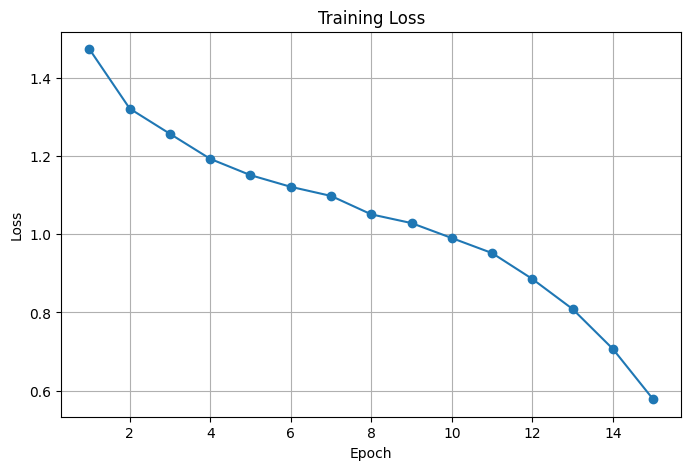

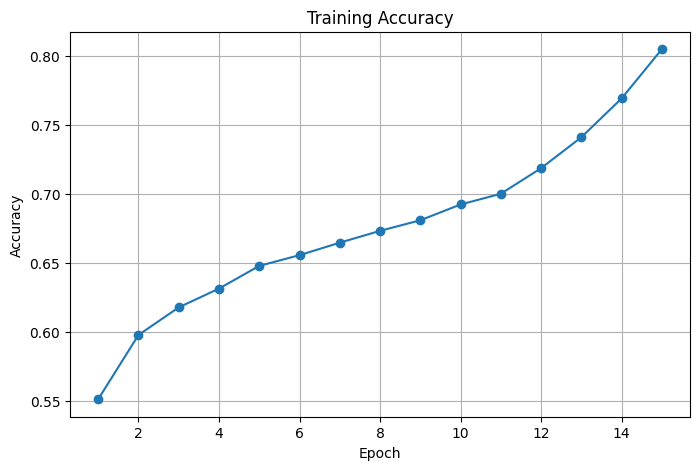

In [41]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from datetime import datetime
import uuid


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)
import numpy as np


# ---------------------------
# W&B 시작
# ---------------------------

run_name = f"weighted_ce_exp1_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_id = uuid.uuid4().hex[:8]

wandb.init(
    project="ham10000-resnet18",
    name="weighted-ce-exp1",
    config={
        "epochs": 15,
        "max_train_batches": 30,
        "optimizer": "Adam",
        "lr": 0.001,
        "loss": "CrossEntropyLoss_weighted",
        "class_weights": [4, 4, 4, 4, 3, 1, 4],
        "model": "ResNet18"
    }
)
max_train_batches = 30

class_weights = torch.tensor([4, 4, 4, 4, 3, 1, 4], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []
val_macro_f1s =[]
val_balanced_accuracies = []



import gc
gc.collect()
torch.cuda.empty_cache()

scaler = torch.amp.GradScaler("cuda")

for epoch in range(epochs) :
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0
  train_steps=0

  for batch_idx, (data, target) in enumerate(train_loader):
    data = data.to(device)
    target = target.to(device)

    optimizer.zero_grad()

    with torch.amp.autocast("cuda"):
      output = model(data)
      loss = criterion(output, target)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    running_loss += loss.item()
    train_steps += 1

    _, preds = torch.max(output, 1)
    correct += (preds == target).sum().item()
    total += target.size(0)

  avg_loss = running_loss/ train_steps
  acc = correct / total



      # for epoch in range(epochs):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0
#     train_steps = 0

#     for batch_idx, (data, target) in enumerate(train_loader):
#     #    if batch_idx >= max_train_batches:
#      #       break
# # 여기가 의미가 무엇이냐면, 위에서 배치사이즈가 32인데, 여기서 50개로 제한을 한다는 것은
# # 한 번 학습시킬때, 이렇게 된 데이터셋을 50번만 꺼내쓴다 이런 의미가 된다
#          data = data.to(device)
#          target = target.to(device)

#          optimizer.zero_grad()
#          output = model(data)
#          loss = criterion(output, target)

#          loss.backward()
#          optimizer.step()

#          running_loss += loss.item()
#          train_steps += 1

#          _, preds = torch.max(output, 1)
#          correct += (preds == target).sum().item()
#          total += target.size(0)

#     avg_loss = running_loss / train_steps
#     acc = correct / total

  train_losses.append(avg_loss)
  train_accuracies.append(acc)
  model.eval()

  val_running_loss = 0.0
  val_steps = 0
  val_preds = []
  val_targets = []

  with torch.no_grad():
    for data, target in val_loader:
      data = data.to(device)
      target = target.to(device)

      output = model(data)
      loss = criterion(output, target)

      val_running_loss += loss.item()
      val_steps += 1

      preds = torch.argmax(output, dim=1)

      val_preds.extend(preds.cpu().numpy())
      val_targets.extend(target.cpu().numpy())

    val_loss = val_running_loss / val_steps
    val_acc = accuracy_score(val_targets, val_preds)
    val_macro_f1 = f1_score(val_targets, val_preds, average="macro", zero_division =0)
    val_balanced_acc = balanced_accuracy_score(val_targets, val_preds)


    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_macro_f1s.append(val_macro_f1)
    val_balanced_accuracies.append(val_balanced_acc)


    print(
         f"Epoch {epoch+1}/{epochs}, "
         f"Train Loss: {avg_loss:.4f}, Train Acc : {acc:.4f}, "
         f"Val Loss : {val_loss:.4f}, Val Acc : {val_acc:.4f}, "
         f"Val Macro F1 : {val_macro_f1:.4f}"
     )

print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {acc:.4f}")

# Loss 그래프
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

# Accuracy 그래프
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accuracies, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True)
plt.show()


# ---------------------------
# 그래프도 W&B에 업로드
# ---------------------------


model.eval()

test_preds = []
test_targets = []
test_probs = []

with torch.no_grad():
  for data ,target in test_loader:
    data =data.to(device)
    target = target.to(device)

    output = model(data)
    probs = torch.softmax(output, dim=1)
    preds = torch.argmax(probs, dim=1)

    test_preds.extend(preds.cpu().numpy())
    test_targets.extend(target.cpu().numpy())
    test_probs.extend(probs.cpu().numpy())

test_probs = np.array(test_probs)

precision, recall, f1, support = precision_recall_fscore_support(
    test_targets,
    test_preds,
    labels=list(range(len(all_classes))),
    zero_division =0
)

class_metrics_table = wandb.Table(
    columns=["class", "precision", "recall", "f1", "support"]
)

for i, class_name in enumerate(all_classes):
  class_metrics_table.add_data(
      class_name,
      float(precision[i]),
      float(recall[i]),
      float(f1[i]),
      int(support[i])
  )


wandb.log({
    "train_loss_curve": wandb.plot.line_series(
        xs=list(range(1, epochs + 1)),
        ys=[train_losses],
        keys=["train_loss"],
        title="Training Loss Curve",
        xname="Epoch"
    ),
    "train_accuracy_curve": wandb.plot.line_series(
        xs=list(range(1, epochs + 1)),
        ys=[train_accuracies],
        keys=["train_accuracy"],
        title="Training Accuracy Curve",
        xname="Epoch"
    ),

    "train_vs_val_loss_curve": wandb.plot.line_series(
        xs =list(range(1, epochs +1)),
        ys = [train_losses, val_losses],
        keys=['train_loss', "val_loss"],
        title="Train vs Validation Loss",
        xname = "Epoch"
    ),

    "val_macro_f1_curve" : wandb.plot.line_series(
        xs =list(range(1, epochs+1)),
        ys = [val_macro_f1s],
        keys=["val_macro_f1"],
        title="Validation macro F1 Curve",
        xname="Epoch"

    ),
    "test_confusion_matrix": wandb.plot.confusion_matrix(
        y_true=test_targets,
        preds=test_preds,
        class_names = all_classes,
        title ="Test Confusion Matrix"
    ),

    "Class_metrics_table": class_metrics_table,

    "test_recall_by_class":wandb.plot.bar(
        class_metrics_table,
        "class",
        "recall",
        title="Test Recall by Class"
    ),

    "test_precision_by_class":wandb.plot.bar(
        class_metrics_table,
        "class",
        "precision",
        title="TestPrecision by Class"
    ),

    "test_f1_by_class": wandb.plot.bar(
        class_metrics_table,
        "class",
        "f1",
        title = "Test F1 by Class"
    ),

    "test_roc+curve":wandb.plot.roc_curve(
        test_targets,
        test_probs,
        labels= all_classes
    ),

    "test_pr_curve":wandb.plot.pr_curve(
        test_targets,
        test_probs,
        labels=all_classes
    )




})

wandb.finish()

In [ ]:
import pandas as pd

bcn_df = pd.read_csv("bcn20000_metadata_2026-04-16.csv")
bcn_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'bcn20000_metadata_2026-04-16.csv'

In [ ]:
label2idx

TypeError: Invalid shape (224, 224, 5) for image data

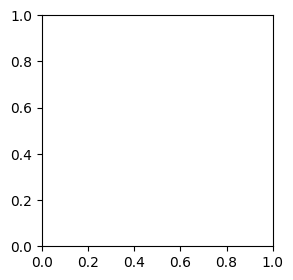

In [ ]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, labels = next(iter(test_loader))   # test_loader에서 한 배치 가져오기
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images_cpu = images.cpu()
labels_cpu = labels.cpu()
preds_cpu = preds.cpu()

for i in range(5):   # 5장만 보기
    img = images_cpu[i].permute(1, 2, 0).numpy()

    pred_label = idx2label[preds_cpu[i].item()]
    true_label = idx2label[labels_cpu[i].item()]
    correct = pred_label == true_label

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(f"pred: {pred_label}\ntrue: {true_label}\ncorrect: {correct}")
    plt.axis("off")
    plt.show()

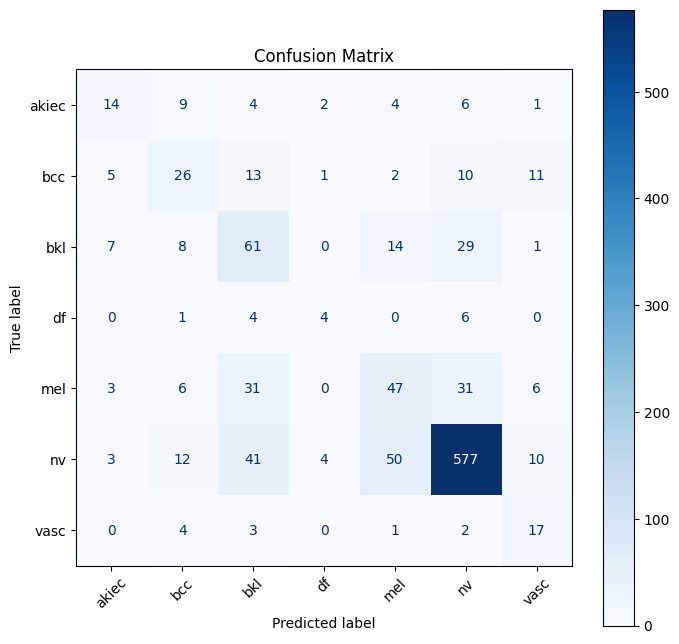

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in val_loader:   # test_loader 써도 됨
        data = data.to(device)
        target = target.to(device)

        output = model(data)
        _, preds = torch.max(output, 1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

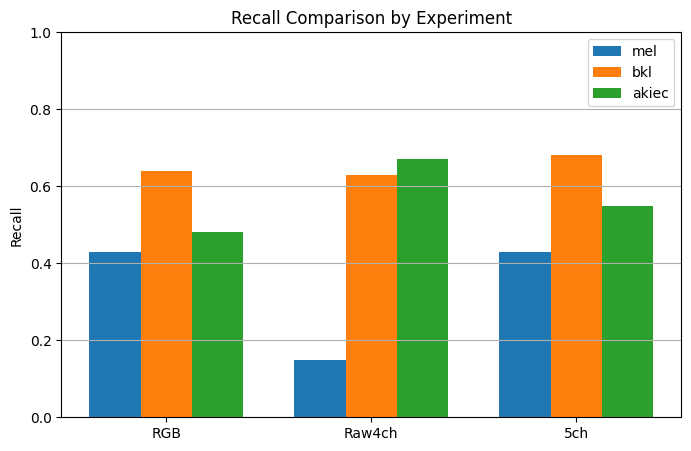

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

experiments = ["RGB", "Raw4ch", "5ch"]
mel_recall = [0.43, 0.15, 0.43]
bkl_recall = [0.64, 0.63, 0.68]
akiec_recall = [0.48, 0.67, 0.55]

x = np.arange(len(experiments))
w = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - w, mel_recall, width=w, label="mel")
plt.bar(x, bkl_recall, width=w, label="bkl")
plt.bar(x + w, akiec_recall, width=w, label="akiec")

plt.xticks(x, experiments)
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title("Recall Comparison by Experiment")
plt.legend()
plt.grid(axis="y")
plt.show()

In [ ]:
#이해를 하고 넘어가야 할 듯

# 먼저, 4채널로 쓸거다


#그리고 나서 AddTextureChannel 이라는 클래스를 이제 transform 처럼 사용하려고 한다
# 그랫 ㅓtransform 내부에 이걸 선언을 해서 사용하려고 만듦
# 그 다음에 def__call__ 이 부분은 이 객체를 함수처럼 부르기 위해서임
# 그래서 이렇게 하면 입력 x를 받아 가공해서 다시 반환하도록 만든거임


#그리고 gray 를 만드는 이유?   이 sobel 이 경계검출이라는 의미인듯 한데
#얘가 이제 흑백 한 장에서 밝기 변화를 보는 게 더 간단하고 흔하기 때문이다

# 그래서 먼저 grya로 바꾸는 거
#gray = gray.unsqueeze(0),unsqueeze(0) 이게 있는데, ㅇ게 첫번째는 channel 추가, 두번째는 bath 추가래
# 왜냐하면 gray 계산 직후가 (H,W)인데, 이때 이걸 (batch, channel, weight, width) 이렇게 추가해주는 건가봐

 # 그 다음에 sobel 코드를 보면 , 뭐 그냥 희한하게 생겼는데, 이게 이제
# 각각좌우 밝기, 그리고 상하 밝기를 나타내기 위해서임
#그리고 나서 이걸 뒤에 view(1, 1, 3, 3) 이렇게 해주는 거는 conv2d에 맞게 변형 시켜주기 위함
#

#두 방향의 각각 변화량을 구하기 위해 gx, gy를 쓰는데 이거 음 일단 패스
# 그 다음에 이걸 갖다가 경게 세기로 만들고 싶은데 이 때 두 방향을 합쳐서 구하려고 하는거임
#그러니까 일종의 뭐 norm2 라고 할 수 있겠네
#내적이라고 봐야하나? 그리고 이제 1e-6으로 나눠서 좀 작게 만듦


#그리고 이제 return torch.cat([x, grad_mag], dim=0)
#이렇게 해서 서로 이어붙여준다

In [ ]:
print(train_dataset)
print(val_dataset)

In [ ]:
print(train_dataset[0][0].shape)
print(train_dataset[0][0].min(), train_dataset[0][0].max())


print(train_df["dx"].value_counts(normalize=True))
print(val_df["dx"].value_counts(normalize=True))

print(class_weights)
print(criterion)

In [ ]:
image, label = vis_dataset[0]   # Normalize 없는 dataset 추천

rgb = image[:3].permute(1,2,0).numpy()
ch4 = image[3].numpy()
ch5 = image[4].numpy()

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(ch4, cmap="gray")
plt.title("Channel 4")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(ch5, cmap="gray")
plt.title("Channel 5")
plt.axis("off")

plt.show()

NameError: name 'vis_dataset' is not defined